# Tufa Labs ARC3 submission

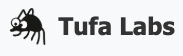

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["thtennant/taaf-kaggle-source-share-fork", "driessmit1/arc3-vllm-h100-wheelhouse-v3"]
# --- v21: Qwen3.8-27B-FP8 model pin ------------------------------------------
# The one axis this project has never varied. Everything else in this notebook
# is byte-identical to v20; see scripts/build_v21_notebook.py.
QWEN_MODEL_OWNER = "foysalemonshanto"
QWEN_MODEL_SLUG = "qwen3-8-27b-fp8-repacked-v1"
QWEN_MODEL_REF = f"{QWEN_MODEL_OWNER}/{QWEN_MODEL_SLUG}"
QWEN_MODEL_FRAMEWORK = "pytorch"
QWEN_MODEL_VARIATION = "hf-fp8"
QWEN_MODEL_VERSION = "1"
QWEN_SERVED_MODEL_NAME = "Qwen/Qwen3.8-27B-FP8"

# Keep the whole run offline: the weights are mounted, nothing may be fetched.
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"


# A Kaggle *Model* does not mount where a Kaggle *dataset* does. The documented
# layout is /kaggle/input/models/<owner>/<slug>/<framework>/<variation>/<version>,
# but the framework segment's case has been seen both ways and some images drop
# the "models" prefix, so probe every shape rather than hard-coding one and
# discovering the mistake 12h into a GPU run.
def _model_mount_candidates() -> list:
    roots = [Path("/kaggle/input/models") / QWEN_MODEL_OWNER / QWEN_MODEL_SLUG,
             Path("/kaggle/input/models") / QWEN_MODEL_SLUG,
             Path("/kaggle/input") / QWEN_MODEL_SLUG]
    frameworks = [QWEN_MODEL_FRAMEWORK, QWEN_MODEL_FRAMEWORK.capitalize(), "PyTorch"]
    seen, out = set(), []
    for root in roots:
        for framework in frameworks:
            candidate = root / framework / QWEN_MODEL_VARIATION / QWEN_MODEL_VERSION
            if str(candidate) not in seen:
                seen.add(str(candidate))
                out.append(candidate)
    return out


_qwen_candidates = _model_mount_candidates()
QWEN_MODEL_PATH = next((c for c in _qwen_candidates if c.is_dir()), None)
if QWEN_MODEL_PATH is None:
    raise FileNotFoundError(
        "Qwen3.8 Kaggle Model is not attached. Tried:\n  "
        + "\n  ".join(str(c) for c in _qwen_candidates)
        + "\nAttach: Qwen3.8 27B FP8 Repacked -> PyTorch -> hf-fp8 -> Version 1"
    )

# Fail before the wheelhouse install rather than inside vLLM: a half-mounted
# checkpoint costs a whole GPU session to discover otherwise.
_qwen_required = [
    "config.json",
    "model.safetensors.index.json",
    "tokenizer.json",
    "tokenizer_config.json",
    "chat_template.jinja",
]
_qwen_missing = [n for n in _qwen_required if not (QWEN_MODEL_PATH / n).is_file()]
if _qwen_missing:
    raise FileNotFoundError(
        f"Qwen3.8 mount {QWEN_MODEL_PATH} is incomplete; missing: " + ", ".join(_qwen_missing)
    )
_qwen_shards = sorted(QWEN_MODEL_PATH.glob("*.safetensors"))
if len(_qwen_shards) != 18:
    raise RuntimeError(
        f"Unexpected Qwen3.8 checkpoint layout: {len(_qwen_shards)} safetensors files, expected 18."
    )
print(f"taaf.kaggle: qwen3.8 model = {QWEN_MODEL_PATH} ({len(_qwen_shards)} shards)")
# -----------------------------------------------------------------------------
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# The bundled setup resolves weights by owner/slug through THIS map first, so
# mapping the model ref to its mounted directory is the whole path fix.
kaggle_input_paths[QWEN_MODEL_REF] = str(QWEN_MODEL_PATH)

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
    "TAAF_QWEN_MODEL_PATH": str(QWEN_MODEL_PATH),
    "TAAF_QWEN_SERVED_MODEL_NAME": QWEN_SERVED_MODEL_NAME,
    "HF_HUB_OFFLINE": "1",
    "TRANSFORMERS_OFFLINE": "1",
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# --- v21: rewrite the bundled setup's model identity --------------------------
# The bundle ships ONE setup command: a here-doc Python script that starts vLLM.
# Rather than fork it (and inherit the job of keeping a 10KB copy in step), we
# rewrite exactly the three top-level string assignments that name the model,
# and raise if any of them is missing -- a bundle that has drifted must fail
# loudly, never serve the old model under the new label.
import re as _re


def _replace_python_assignment(command: str, variable_name: str, value: str):
    pattern = rf"(?m)^{_re.escape(variable_name)}\s*=\s*(['\"])[^\r\n]*?\1\s*$"
    return _re.subn(pattern, f"{variable_name} = {value!r}", command, count=1)


def _patch_qwen38_setup_commands(commands: list) -> list:
    replacements = {
        "MODEL_OWNER": QWEN_MODEL_OWNER,
        "MODEL_SLUG": QWEN_MODEL_SLUG,
        "SERVED_MODEL_NAME": QWEN_SERVED_MODEL_NAME,
    }
    counts = {name: 0 for name in replacements}
    env_patches = 0
    patched = []
    for raw in commands:
        command = str(raw)
        for name, value in replacements.items():
            command, n = _replace_python_assignment(command, name, value)
            counts[name] += n
        # Make the offline pins explicit in the vLLM child process too.
        if "def vllm_env()" in command and "'VLLM_NO_USAGE_STATS': '1'," in command:
            command = command.replace(
                "'VLLM_NO_USAGE_STATS': '1',",
                "'VLLM_NO_USAGE_STATS': '1',\n"
                "            'HF_HUB_OFFLINE': '1',\n"
                "            'TRANSFORMERS_OFFLINE': '1',",
                1,
            )
            env_patches += 1
        patched.append(command)
    missing = [name for name, n in counts.items() if n == 0]
    if missing:
        raise RuntimeError(
            "Could not repoint the bundled setup at Qwen3.8; missing assignment(s): "
            + ", ".join(missing)
            + ". The attached source bundle's setup_commands.json has changed."
        )
    print(f"taaf.kaggle: qwen3.8 setup patch = {counts}, vllm_env offline patches = {env_patches}")
    return patched
# -----------------------------------------------------------------------------

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
_setup_commands = _patch_qwen38_setup_commands(json.loads((BUNDLE_DIR / "setup_commands.json").read_text()))
for command in _setup_commands:
    print(f"taaf.kaggle: setup command: {command}", flush=True)
    subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
    # Re-read in case the command persisted new env keys.
    env = _command_env()
    os.environ.update(env)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

# The gate that stops a silently-failed patch shipping a Qwen3.6 run labelled
# Qwen3.8: the bundled setup exports the served id it actually started.
_served = os.environ.get("INFERENCE_ANALYZER_MODEL", "")
if _served != QWEN_SERVED_MODEL_NAME:
    raise RuntimeError(
        f"setup completed but the analyzer model id is {_served!r}, expected {QWEN_SERVED_MODEL_NAME!r}"
    )
print(f"TAAF_MODEL_PIN SERVED_MODEL_NAME={_served} MODEL_PATH={QWEN_MODEL_PATH}")


In [ ]:
# Boot attestation (doctrine v2, 2026-08-17): the mounted weights must be the
# OFFICIAL Qwen3.8-FP8. Discriminators verified offline against both the
# official HF snapshot and the vrfai 3.6 config: 3.8 = quant_method fp8 /
# fmt e4m3 / transformers 5.8.0.dev0; 3.6-vrfai = compressed-tensors
# config_groups / transformers 5.6.2. A wrong mount must DIE here, before any
# game action is spent. --served-model-name is a rename and proves nothing.
import hashlib as _hashlib
import urllib.request as _rq

_cfg_path = QWEN_MODEL_PATH / "config.json"
_cfg_raw = _cfg_path.read_bytes()
_cfg = json.loads(_cfg_raw)
_q = _cfg.get("quantization_config") or {}
assert _cfg.get("architectures") == ["Qwen3_5ForConditionalGeneration"], (
    f"attest FAIL: architectures {_cfg.get('architectures')}")
assert _q.get("quant_method") == "fp8" and _q.get("fmt") == "e4m3", (
    f"attest FAIL: quantization_config is not official fp8/e4m3: {_q}")
assert _cfg.get("transformers_version") == "5.8.0.dev0", (
    f"attest FAIL: transformers_version {_cfg.get('transformers_version')} "
    "(vrfai 3.6 stamps 5.6.2)")
print("attest: config sha256", _hashlib.sha256(_cfg_raw).hexdigest())

_idx_path = QWEN_MODEL_PATH / "model.safetensors.index.json"
if _idx_path.is_file():
    print("attest: index sha256", _hashlib.sha256(_idx_path.read_bytes()).hexdigest())
_shards = sorted(QWEN_MODEL_PATH.glob("*.safetensors"))
assert _shards, "attest FAIL: no safetensors shards at model path"
_total = sum(p.stat().st_size for p in _shards)
print(f"attest: {len(_shards)} shards, {_total} bytes total")
assert _total > 25_000_000_000, f"attest FAIL: total shard bytes {_total} too small for 27B FP8"
_h = _hashlib.sha256()
with open(_shards[0], "rb") as _f:
    _h.update(_f.read(1 << 20))
print("attest: first-shard-1MiB sha256", _h.hexdigest())

# Greedy decode fingerprint — logged (not asserted) for cross-run comparison.
_base = (os.environ.get("LOCAL_ANALYZER_BASE_URL") or "http://127.0.0.1:1234/v1").rstrip("/")
if not _base.endswith("/v1"):
    _base += "/v1"
_body = json.dumps({
    "model": QWEN_SERVED_MODEL_NAME,
    "messages": [{"role": "user", "content": "Reply with exactly the sum of 17 and 25, then the word quack."}],
    "temperature": 0.0,
    "max_tokens": 48,
    "chat_template_kwargs": {"enable_thinking": False},
}).encode()
_req = _rq.Request(_base + "/chat/completions", data=_body, headers={
    "Content-Type": "application/json",
    "Authorization": "Bearer " + (os.environ.get("LOCAL_ANALYZER_API_KEY") or "EMPTY"),
})
with _rq.urlopen(_req, timeout=180) as _resp:
    _reply = json.loads(_resp.read())["choices"][0]["message"].get("content") or ""
print("attest: decode fingerprint", repr(_reply)[:160])
print("attest: decode sha256", _hashlib.sha256(_reply.encode()).hexdigest())
print("attest: OK — official Qwen3.8-FP8 signature verified before any game")


## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# Make one-off changes to `bm`, `bm.games`, or `bm.solver` here before the run starts.
# Example:
# bm.label = f"{bm.label}-debug"

# Composite graft install (v22 = the v12 floor + goalkeep + hudmask + clickmap + searchmap): the single cell-12
# entry point shipped in our
# goalkeep stops the agent's carried world model being wiped on every game over /
# level change (measured: the stock harness carried a non-empty model on only
# 33 of 481 turns) and injects a compact digest of MEASURED outcomes -- per-action
# board-change rates, level completions, game-over cadence -- every turn.
# hudmask segments the status/timer band out of that change signal. board_changed
# is a whole-frame diff, so on 10 of the 25 public games it is true 100% of the
# time and the rate table carries zero bits (tn36's live v18 prompt read
# 'MOUSE 61/61'). The band is discovered from play alone by action-independence
# -- a row/column every base action drives at >=90% is a HUD, one that any action
# leaves alone is gameplay -- learned once and reused for every later level of the
# game, with earlier evidence re-scored retroactively once the band is found.
# Measured offline on all 25 public games: informative action tables 15 -> 23,
# and the 17 games where no band exists are bit-identical.
# clickmap breaks the single MOUSE bucket down by WHAT WAS UNDER THE CURSOR.
# goalkeep has to aggregate by base action -- a click carries coordinates, so keying
# on the display string gives one bucket per pixel -- which means the entire measured
# world model of a 4096-way action space is one number (the live v19 run told the
# agent 'MOUSE 72/100'). clickmap keys the change ledger on two game-agnostic
# properties of the clicked cell in the before-frame: its colour, and the size of the
# contiguous same-colour block it belongs to, backing off from the conjunction to
# either marginal. Measured prequentially on the real recorded v19 commit run (291
# clicks): Brier 0.1414 -> 0.0627 against goalkeep's single rate, and 21 'this kind
# of click has never done anything' claims at 0.952 precision. On a uniform-random
# control over all 19 public games that accept clicks (5700 clicks) it is better on
# 16 of 19 and never worse by more than 0.007. It also reports its own falsifications:
# when a kind of click that had been inert for >=5 tries suddenly works, the digest
# says so with the count and the action number, rather than quietly updating a rate.
# searchmap reports the STRUCTURE of the action space, which is the thing the agent
# needs in order to work out what it is even optimising. The reward channel cannot
# tell it: the harness builds reward as (levels_completed - previous)/number_of_levels,
# i.e. level_completed rescaled, and on the real v21 commit run that fired ONCE in
# 375 actions -- three of the four games never saw a positive reward at all. So the
# agent falls back on the per-action change rate, which on click games is saturated
# (real tn36: 'MOUSE 144/150', ~0.24 bits).
# What that boolean hides, measured on the real run: tn36 changes exactly 3 cells on
# every one of 150 actions, 99% co-located with the click, from only 16 distinct
# targets -- 15 of which have only ever shown TWO local patterns. It is not a
# 4096-cell click space; it is sixteen binary switches hammered nine times each,
# with 37% of actions returning the play area to a configuration already visited.
# searchmap reports coverage and revisits (both pure counting over what happened),
# and -- gated -- the switch reading, which reframes the level as a COMBINATION
# rather than a sequence. That last one is an inference, so it was put through the
# same prequential test that RETIRED the deadend graft at 0.486: label from the past
# only, score every later visit against a future the label could not see. It scores
# 0.974/0.980/0.977/0.969 at support >=2/3/4/6 -- holding up as evidence accumulates,
# where deadend degraded -- and every residual error was a lone two-pattern site on a
# game that is not a switch puzzle. Gated on a quorum of 3 agreeing sites it is
# 113/113, precision 1.0000, firing on tn36 only, available from action 27 of 150.
# Nothing is game-specific: it reads action targets and cell diffs.
# forked source bundle (thtennant/taaf-kaggle-source-share-fork, src/taaf-grafts),
# importable here because the source-import cell above put every bundled repo on
# sys.path. install(bm, flags) wires the EfficiencyToolAgent analyzer (budget-aware
# per-turn note + net-zero waste detection, report-only) plus the RetryGuard
# analyzer chain layer (a proven pass-through rider) plus shortcircuit (no-op
# overshoot trimmer), printing the machine-parseable
# 'TAAF_GRAFTS FEATURES={...} API_VERSION=1' banner the commit-log gate reads.
# The run cell below reassigns bm.games (offline dup-game gate included) but never
# touches bm.solver, so swapping the solver instance here is safe: Benchmark.run
# deepcopies whatever solver is present at run time.
# install() is itself blanket-guarded (restores the original bm.solver on ANY
# error); the extra try/except-pass here is belt-and-suspenders so even an import
# failure of composite leaves bm.solver untouched (stock HarnessSolver).
try:
    from taaf_grafts.composite import install

    install(bm, flags={"efficiency": True, "retry_guard": True, "shortcircuit": True, "goalkeep": True, "hudmask": True, "clickmap": True, "searchmap": True})
except Exception as exc:  # noqa: BLE001 — any graft failure must fall back to stock
    print(f"[taaf_grafts] cell-12 graft failed, running stock: {type(exc).__name__}: {exc}")


## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Print the run preamble and persist the launcher's git status for diagnostics.
print((BUNDLE_DIR / "preamble.txt").read_text())
(WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    bm.games = _offline_games(competition_env_files)

# Safety pack + dup-game commit gate: keep interactive commit runs short AND make
# the transfer family store fire. Provably inert in a real rerun (guarded on
# TRUE_SUBMISSION); it must live in this cell, after the branches above, because
# both branches reassign bm.games (cell 12 runs first). The duplicate is the SAME
# env as games[0] added via GameAPI.external_game_id (game_api.py:155) — Benchmark's
# unique-game_id check (benchmark.py:160) is satisfied because the dup carries a
# distinct game_id, while the shared arcade_spec keeps it in games[0]'s fingerprint
# family: games[0] scouts and publishes, the dup replays. Any construction fault
# falls back to the plain [:4] truncation.
if not TRUE_SUBMISSION:
    try:
        import taaf.game_api

        first = bm.games[0]
        bm.games = bm.games[:3] + [
            taaf.game_api.GameAPI(
                env_name=first.env_name,
                arcade_spec=first.arcade_spec,
                external_game_id=f"{first.env_name}-dup",
            )
        ]
    except Exception as exc:  # noqa: BLE001 — any dup fault falls back to plain truncation
        print(f"[taaf_grafts] dup-game gate failed, using [:4]: {type(exc).__name__}: {exc}")
        bm.games = bm.games[:4]

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
soft_end = None
if not TRUE_SUBMISSION:
    budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
    if budget > 0:
        soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(seconds=budget - min(600.0, budget / 2))
else:
    # Safety pack: a real rerun used to run with soft_end=None (no global soft
    # deadline; the wall budget was emergent). Cap at run start + 11h20m so the
    # solver drains and the shared scorecard closes before Kaggle's hard kill.
    soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(hours=11, minutes=20)

# Play the benchmark; teardown commands run even if the run raises.
try:
    await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=TRUE_SUBMISSION)
    if not TRUE_SUBMISSION:
        # An offline run isn't scored, but Kaggle still expects a submission.parquet output.
        import pandas as pd

        pd.DataFrame(
            [["1_0", "1", True, 1]],
            columns=["row_id", "game_id", "end_of_game", "score"],
        ).to_parquet(WORKING_DIR / "submission.parquet", index=False)
finally:
    for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
        print(f"taaf.kaggle: teardown command: {command}", flush=True)
        subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())

## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")